# Ames 房价预测：最终结果复核

本 Notebook 不重新训练模型，而是读取作品包中的 OOF、Kaggle 提交记录和排名证据，复核最终结论。完整训练入口为 `src/train_and_predict.py`。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
RESULTS = ROOT / 'results'
summary = json.loads((RESULTS / 'v3_summary.json').read_text(encoding='utf-8'))
history = pd.read_csv(RESULTS / 'kaggle_submission_history.csv')
rank = pd.read_csv(RESULTS / 'kaggle_rank_snapshot.csv')
oof = pd.read_csv(RESULTS / 'v3_oof_predictions.csv')

## 1. 提交结果

In [2]:
display(history[['Version', 'Description', 'PublicScore', 'RankSnapshot', 'TotalTeams']])
display(rank[['Rank', 'TotalTeams', 'TopPercent', 'Score', 'SnapshotDate']])

,Version,Description,PublicScore,RankSnapshot,TotalTeams
0,V2,Repeated-CV regularized three-model ensemble,0.12205,493,3454
1,V3,Robust CV plus calibrated four-model blend,0.12163,430,3454


,Rank,TotalTeams,TopPercent,Score,SnapshotDate
0,430,3454,12.449334,0.12163,2026-08-24


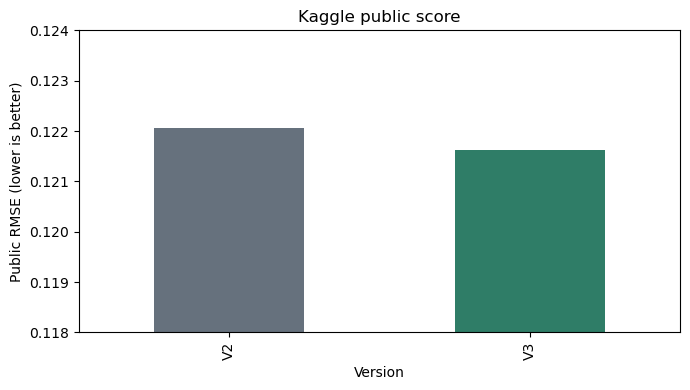

In [3]:
ax = history.plot.bar(x='Version', y='PublicScore', legend=False, color=['#66717D', '#2F7D67'], figsize=(7, 4))
ax.set_ylim(0.118, 0.124)
ax.set_ylabel('Public RMSE (lower is better)')
ax.set_title('Kaggle public score')
plt.tight_layout(); plt.show()

## 2. 最终融合权重

,weight
SVR_RBF,26.48%
ElasticNet_Domain,25.87%
XGBoost,24.29%
GradientBoosting,23.36%


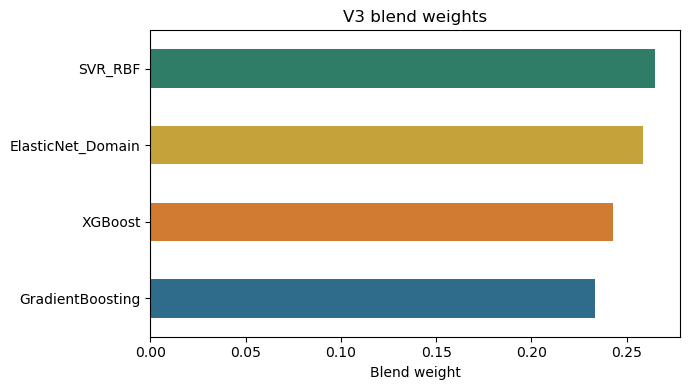

In [4]:
weights = pd.Series(summary['selected_weights'], name='weight').sort_values(ascending=False)
display(weights.to_frame().style.format({'weight': '{:.2%}'}))
weights.sort_values().plot.barh(color=['#2F6B8A', '#D07A32', '#C6A33A', '#2F7D67'], figsize=(7, 4))
plt.xlabel('Blend weight'); plt.title('V3 blend weights'); plt.tight_layout(); plt.show()

## 3. OOF 残差按价格段复核

,RMSE,MeanResidual,Count
price_decile,,,
1,0.19518,-0.07525,146
2,0.09944,0.00098,149
3,0.08710,0.00520,144
4,0.10606,0.00115,150
5,0.08234,0.01621,142
6,0.07493,0.00620,144
7,0.06807,-0.01120,145
8,0.07012,0.00920,149
9,0.09467,0.01112,144


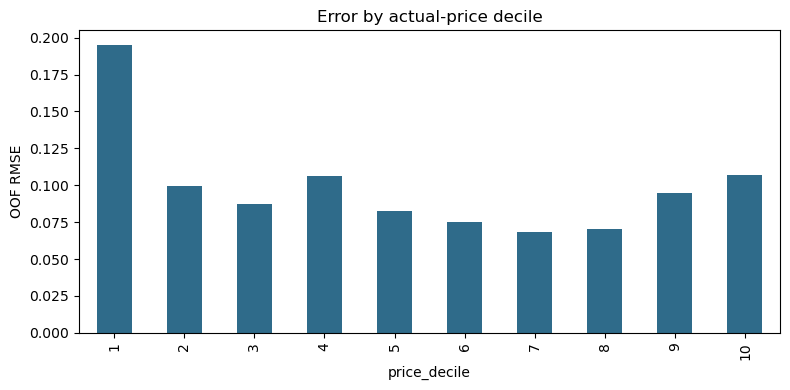

In [5]:
oof['residual'] = oof['actual_log_price'] - oof['calibrated_oof_log']
oof['price_decile'] = pd.qcut(oof['actual_log_price'], 10, labels=False) + 1
decile = oof.groupby('price_decile')['residual'].agg(
    RMSE=lambda x: np.sqrt(np.mean(x**2)), MeanResidual='mean', Count='size'
)
display(decile.style.format({'RMSE': '{:.5f}', 'MeanResidual': '{:.5f}'}))
decile[['RMSE']].plot.bar(color='#2F6B8A', figsize=(8, 4), legend=False)
plt.ylabel('OOF RMSE'); plt.title('Error by actual-price decile'); plt.tight_layout(); plt.show()

## 4. 结论

- V3 Public Score 为 **0.12163**，较 V2 的 0.12205 有小幅改善。
- 排名快照为 **430 / 3,454（Top 12.45%）**。
- 稳健本地交叉验证仍明显优于公开分数，说明验证存在乐观偏差。
- 最低和最高价格段仍是主要误差来源，下一步应优先改进验证独立性与尾部建模。